# News Category Classification

## Stage 1. Problem Statement

The dataset contains news articles with their corresponding categories.

The goal of this project is to train a machine learning model that predicts
the category of a news article based on its textual content.

This is a supervised multiclass text classification problem.

### Why this task is useful

Automatic news classification is a Natural Language Processing (NLP) task.
It can be used to automatically organize large collections of news articles,
making them easier to search, filter, and process.

### Evaluation Metrics

The dataset contains multiple classes with an imbalanced class distribution.
Therefore, the main evaluation metric will be **Macro F1**, while **Accuracy**
will be used as an additional metric.

**Accuracy** measures the proportion of correctly classified examples:

Accuracy = Number of correct predictions / Total number of predictions

**F1-score** combines Precision and Recall:

F1 = 2 × (Precision × Recall) / (Precision + Recall)

For multiclass classification, **Macro F1** is calculated by computing the
F1-score independently for each class and then taking their average.

This gives every class equal importance regardless of how many examples it contains.

In [1]:
from datasets import load_dataset

dataset = load_dataset("heegyu/news-category-dataset")

c:\Users\miste\anaconda3\envs\geron_ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset

DatasetDict({
    train: Dataset({
        features: ['link', 'headline', 'category', 'short_description', 'authors', 'date'],
        num_rows: 209527
    })
})

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = dataset["train"].to_pandas()

## Stage 2. Data Analysis

Before preparing the data and training a model, we first explore the dataset
to understand its structure and identify potential data quality issues.

During this stage we will:

- inspect the dataset structure and several examples;
- check for missing and empty values;
- check for duplicated articles and conflicting labels;
- examine the number and distribution of target classes;
- analyze the length of the article text;
- inspect the date range of the dataset.

No data will be modified at this stage. The goal is to identify potential
problems that should be addressed during data preparation.

### Dataset Overview

In [4]:
df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype        
---  ------             --------------   -----        
 0   link               209527 non-null  str          
 1   headline           209527 non-null  str          
 2   category           209527 non-null  str          
 3   short_description  209527 non-null  str          
 4   authors            209527 non-null  str          
 5   date               209527 non-null  datetime64[s]
dtypes: datetime64[s](1), str(5)
memory usage: 71.2 MB


In [6]:
print(f"Number of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"Columns: {df.columns.tolist()}")

Number of rows: 209527
Number of columns: 6
Columns: ['link', 'headline', 'category', 'short_description', 'authors', 'date']


### Missing and Empty Values

In [7]:
df.isna().sum()

link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
dtype: int64

In [8]:
text_columns = [
    "link",
    "headline",
    "category",
    "short_description",
    "authors",
]

for column in text_columns:
    empty_count = df[column].fillna("").str.strip().eq("").sum()
    print(f"{column}: {empty_count} empty values")

link: 0 empty values
headline: 6 empty values
category: 0 empty values
short_description: 19712 empty values
authors: 37418 empty values


We check whether any articles contain no textual information in either
`headline` or `short_description`.

In [9]:
empty_texts = (
    df["headline"].fillna("").str.strip().eq("")
    & df["short_description"].fillna("").str.strip().eq("")
)

print(f"Articles without text: {empty_texts.sum()}")

df.loc[empty_texts]

Articles without text: 5


,link,headline,category,short_description,authors,date
90944,https://www.huffingtonpost.com/entry/lincoln-2...,,POLITICS,,"Robert Moran, ContributorRobert Moran leads Br...",2015-08-22
103675,https://www.huffingtonpost.com/entry/us-and-eu...,,WORLDPOST,,"Natasha Srdoc, ContributorAuthor, Economist, C...",2015-03-29
109100,https://www.huffingtonpost.com/entry/disney-ce...,,BUSINESS,,"Gary Snyder, ContributorWriter and Media Strat...",2015-01-25
110153,https://www.huffingtonpost.com/entry/beverly-h...,,MEDIA,,"Gary Snyder, ContributorWriter and Media Strat...",2015-01-13
122145,https://www.huffingtonpost.com/entry/beverly-h...,,QUEER VOICES,,"Gary Snyder, ContributorWriter and Media Strat...",2014-08-28


### Duplicates and Conflicting Labels

Duplicated articles may cause data leakage if identical texts appear in both
training and evaluation sets. We therefore check for duplicated texts and
whether identical texts have conflicting category labels.

In [10]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")

Fully duplicated rows: 13


In [11]:
text_duplicates = df.duplicated(
    subset=["headline", "short_description"]
).sum()

print(f"Duplicated articles: {text_duplicates}")

Duplicated articles: 489


In [12]:
conflicting_duplicates = (
    df.groupby(["headline", "short_description"])["category"]
    .nunique()
    .reset_index(name="category_count")
)

conflicting_duplicates = conflicting_duplicates[
    conflicting_duplicates["category_count"] > 1
]

print(f"Conflicting duplicated texts: {len(conflicting_duplicates)}")

Conflicting duplicated texts: 15


In [13]:
conflicting_rows = df.merge(
    conflicting_duplicates[["headline", "short_description"]],
    on=["headline", "short_description"],
    how="inner",
)

conflicting_rows[
    ["headline", "short_description", "category"]
].sort_values(["headline", "short_description"])

,headline,short_description,category
6,,,POLITICS
9,,,WORLDPOST
10,,,BUSINESS
11,,,MEDIA
13,,,QUEER VOICES
27,A Conversation With Decorator and Fashion Desi...,Much like the arresting color combinations she...,HOME & LIVING
28,A Conversation With Decorator and Fashion Desi...,Much like the arresting color combinations she...,STYLE & BEAUTY
18,Bring Back Our Girls,,WOMEN
19,Bring Back Our Girls,,IMPACT
26,Could You Go a Year Without Buying Anything Ne...,There is one thing that sets me apart from the...,STYLE & BEAUTY


### Class Distribution

In [14]:
categories = df["category"].unique()

print(f"Number of categories: {len(categories)}")
print(categories)

Number of categories: 42
<ArrowStringArray>
[     'U.S. NEWS',         'COMEDY',      'PARENTING',     'WORLD NEWS',
 'CULTURE & ARTS',           'TECH',         'SPORTS',  'ENTERTAINMENT',
       'POLITICS',     'WEIRD NEWS',    'ENVIRONMENT',      'EDUCATION',
          'CRIME',        'SCIENCE',       'WELLNESS',       'BUSINESS',
 'STYLE & BEAUTY',   'FOOD & DRINK',          'MEDIA',   'QUEER VOICES',
  'HOME & LIVING',          'WOMEN',   'BLACK VOICES',         'TRAVEL',
          'MONEY',       'RELIGION',  'LATINO VOICES',         'IMPACT',
       'WEDDINGS',        'COLLEGE',        'PARENTS', 'ARTS & CULTURE',
          'STYLE',          'GREEN',          'TASTE', 'HEALTHY LIVING',
  'THE WORLDPOST',      'GOOD NEWS',      'WORLDPOST',          'FIFTY',
           'ARTS',        'DIVORCE']
Length: 42, dtype: str


In [15]:
class_counts = df["category"].value_counts()

class_counts

category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUCATI

In [16]:
class_distribution = df["category"].value_counts(normalize=True) * 100

class_distribution

category
POLITICS          16.991605
WELLNESS           8.564529
ENTERTAINMENT      8.286283
TRAVEL             4.724928
STYLE & BEAUTY     4.683883
PARENTING          4.195641
HEALTHY LIVING     3.194815
QUEER VOICES       3.029204
FOOD & DRINK       3.025863
BUSINESS           2.859775
COMEDY             2.577233
SPORTS             2.423077
BLACK VOICES       2.187308
HOME & LIVING      2.061787
PARENTS            1.887585
THE WORLDPOST      1.748701
WEDDINGS           1.743451
WOMEN              1.704792
CRIME              1.700020
IMPACT             1.662793
DIVORCE            1.635111
WORLD NEWS         1.574499
MEDIA              1.405070
WEIRD NEWS         1.325366
GREEN              1.251390
WORLDPOST          1.230868
RELIGION           1.229913
STYLE              1.075756
SCIENCE            1.052848
TECH               1.004167
TASTE              1.000348
MONEY              0.838078
ARTS               0.720194
ENVIRONMENT        0.689171
FIFTY              0.668649
GOOD NEWS  

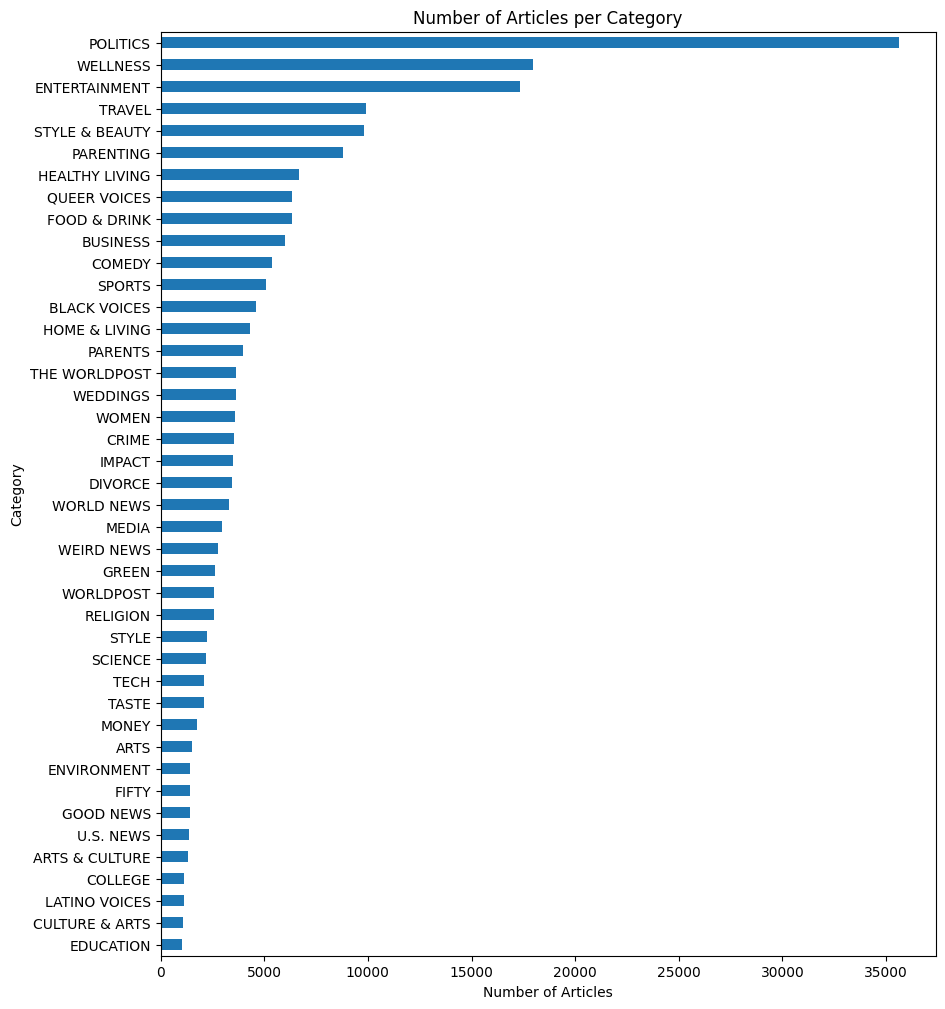

In [17]:
class_counts.sort_values().plot(
    kind="barh",
    figsize=(10, 12),
)

plt.title("Number of Articles per Category")
plt.xlabel("Number of Articles")
plt.ylabel("Category")
plt.show()

The dataset has a noticeable class imbalance. Therefore, accuracy alone may not be sufficient for model evaluation. Class-wise metrics and Macro F1 should also be considered. Techniques such as class weighting may be evaluated during model training.

### Text Length

In [18]:
df["text"] = (
    df["headline"].fillna("")
    + " "
    + df["short_description"].fillna("")
)

df["text_length"] = df["text"].str.split().str.len()

df["text_length"].describe()

count    209527.000000
mean         29.269770
std          13.803927
min           0.000000
25%          20.000000
50%          28.000000
75%          35.000000
max         245.000000
Name: text_length, dtype: float64

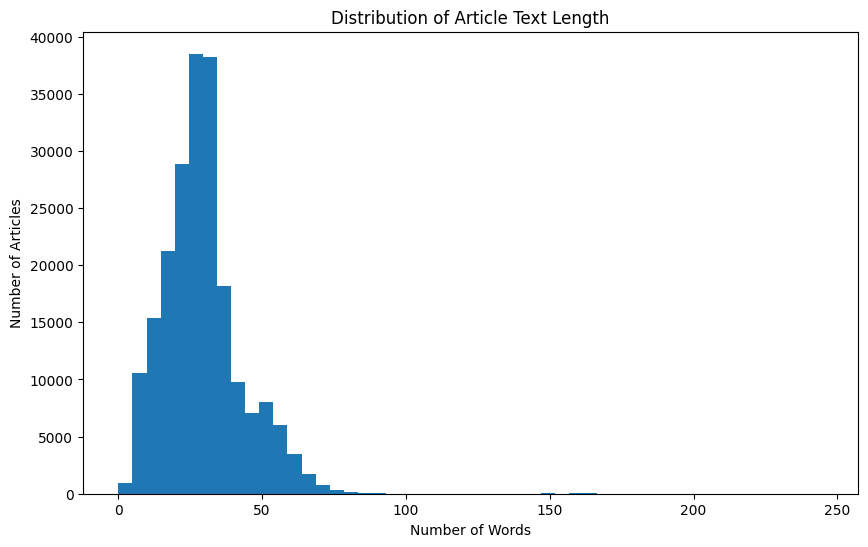

In [19]:
df["text_length"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 6),
)

plt.title("Distribution of Article Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")
plt.show()

### Date Range

In [20]:
dates = pd.to_datetime(df["date"])

print(f"From: {dates.min()}")
print(f"To:   {dates.max()}")

From: 2012-01-28 00:00:00
To:   2022-09-23 00:00:00


### Data Analysis Conclusions

The dataset contains **209,527 news articles** and 6 original columns:
`link`, `headline`, `category`, `short_description`, `authors`, and `date`.

No NaN values were found. However, some textual fields contain empty strings:

- `headline`: 6 empty values;
- `short_description`: 19,712 empty values;
- `authors`: 37,418 empty values.

There are **5 articles where both `headline` and `short_description` are empty**.
These examples contain no textual information that can be used for classification
and will need to be handled during data preparation.

The dataset contains:

- 13 fully duplicated rows;
- 489 repeated `headline + short_description` entries;
- 15 groups of identical texts assigned to more than one category.

The conflicting labels represent a data quality issue that should be resolved
before splitting and training the model.

The target variable `category` contains **42 classes**.
The class distribution is noticeably imbalanced. The largest class, `POLITICS`,
contains 35,602 examples (about 17% of the dataset), while the smallest class,
`EDUCATION`, contains 1,014 examples (about 0.48%).

Because of this imbalance, class-wise performance and Macro F1 will be important
when evaluating the model.

For the combined `headline + short_description` text:

- mean length: about 29 words;
- median length: 28 words;
- 75% of articles contain no more than 35 words;
- maximum length: 245 words.

These values represent whitespace-separated words rather than tokenizer tokens.
The actual token sequence lengths will be analyzed later when a tokenizer is selected.

The articles cover the period from **January 28, 2012 to September 23, 2022**.

## Stage 3. Data Preparation

Before splitting the dataset and training the models, we prepare the data
based on the issues identified during exploratory data analysis.

For the main classification task, the model will predict `category` using
the textual content of an article:

- `headline`
- `short_description`

At this stage, we first perform deterministic data cleaning:

1. remove articles that contain no textual information;
2. remove groups of identical texts with conflicting category labels;
3. remove repeated texts with the same label, keeping only one occurrence.

Removing duplicated texts before the train/validation/test split also prevents
the same article from appearing in multiple subsets and causing data leakage.

Feature selection, dataset splitting, and handling class imbalance will be
considered separately after the basic cleaning step.

In [21]:
df_clean = df.copy()

print(f"Initial number of articles: {len(df_clean)}")

Initial number of articles: 209527


In [22]:
print(f"Articles without text: {empty_texts.sum()}")

df_clean = df_clean.loc[~empty_texts].copy()

Articles without text: 5


In [23]:
category_count_per_text = (
    df_clean
    .groupby(["headline", "short_description"])["category"]
    .transform("nunique")
)

conflicting_mask = category_count_per_text > 1

print(
    "Rows belonging to conflicting text groups:",
    conflicting_mask.sum(),
)

df_clean = df_clean.loc[~conflicting_mask].copy()

Rows belonging to conflicting text groups: 29


In [24]:
duplicates_before = df_clean.duplicated(
    subset=["headline", "short_description"]
).sum()

print(f"Duplicated texts remaining: {duplicates_before}")

df_clean = df_clean.drop_duplicates(
    subset=["headline", "short_description"],
    keep="first",
).copy()

Duplicated texts remaining: 470


Fully duplicated rows do not require a separate cleaning step because they are a subset of duplicated headline + short_description entries and are removed by the same operation.

In [25]:
empty_texts_after = (
    df_clean["headline"].fillna("").str.strip().eq("")
    & df_clean["short_description"].fillna("").str.strip().eq("")
).sum()

duplicated_texts_after = df_clean.duplicated(
    subset=["headline", "short_description"]
).sum()

conflicts_after = (
    df_clean
    .groupby(["headline", "short_description"])["category"]
    .nunique()
    .gt(1)
    .sum()
)

print(f"Articles without text: {empty_texts_after}")
print(f"Duplicated texts: {duplicated_texts_after}")
print(f"Conflicting text groups: {conflicts_after}")
print(f"Remaining articles: {len(df_clean)}")
print(f"Removed articles: {len(df) - len(df_clean)}")

Articles without text: 0
Duplicated texts: 0
Conflicting text groups: 0
Remaining articles: 209023
Removed articles: 504


### Feature Selection, Data Splitting and Class Imbalance

After basic data cleaning, we need to decide which fields will be used by the model,
how the dataset will be split, and how class imbalance will be handled.

#### Feature Selection

The goal of the project is to predict the category of a news article based on its
textual content. Therefore, the model input will consist of:

- `headline`
- `short_description`

These fields will be combined into a single `text` feature.

The remaining fields will not be used as model inputs:

- `link` is an article identifier/metadata field and does not represent the article
  content. It may also contain patterns specific to the source website that would not
  generalize to other news data.
- `authors` may correlate strongly with particular categories because some authors
  specialize in specific topics. Using it could allow the model to rely on the author
  identity instead of learning the meaning of the article text. It also contains many
  empty values.
- `date` may correlate with changes in topics over time, but the goal of this project
  is text classification rather than prediction based on temporal metadata.

The target variable is `category`.

#### Train / Validation / Test Split

The cleaned dataset will be divided into:

- 80% training data;
- 10% validation data;
- 10% test data.

The split will be stratified by `category` so that all three subsets preserve
approximately the same class distribution.

A fixed random seed will be used to make the split reproducible.

Duplicated texts were removed before splitting, which prevents the same article
from appearing in more than one subset and causing data leakage.

The validation set will be used for model selection and tuning.
The test set will remain untouched until the final evaluation.

#### Class Imbalance

The dataset contains a noticeable class imbalance.

We will not use oversampling or undersampling initially because even the smallest
classes still contain a substantial number of examples, and resampling would either
duplicate data or discard real observations.

Instead, we will compare two training strategies:

1. a baseline model trained without class weighting;
2. the same approach using class weights calculated only from the training set.

This will allow us to measure whether class weighting actually improves performance,
especially Macro F1, rather than assuming that it is necessary.

Class weights will be calculated using only the training subset to avoid using
information from the validation or test sets during training.

In [26]:
df_prepared = df_clean.copy()

df_prepared["text"] = (
    df_prepared["headline"].fillna("").str.strip()
    + " "
    + df_prepared["short_description"].fillna("").str.strip()
).str.strip()

df_prepared = df_prepared[["text", "category"]].copy()

print(f"Prepared articles: {len(df_prepared)}")

df_prepared.head()

Prepared articles: 209023


,text,category
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY
3,The Funniest Tweets From Parents This Week (Se...,PARENTING
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS


In [27]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_prepared,
    test_size=0.2,
    stratify=df_prepared["category"],
    random_state=42,
)

In [28]:
validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["category"],
    random_state=42,
)

In [29]:
print(f"Train:      {len(train_df)}")
print(f"Validation: {len(validation_df)}")
print(f"Test:       {len(test_df)}")

print(
    f"\nTotal: {len(train_df) + len(validation_df) + len(test_df)}"
)

Train:      167218
Validation: 20902
Test:       20903

Total: 209023


In [30]:
split_class_distribution = pd.DataFrame({
    "full": df_prepared["category"].value_counts(normalize=True),
    "train": train_df["category"].value_counts(normalize=True),
    "validation": validation_df["category"].value_counts(normalize=True),
    "test": test_df["category"].value_counts(normalize=True),
})

split_class_distribution

,full,train,validation,test
category,,,,
ARTS,0.007219,0.007218,0.007224,0.007224
ARTS & CULTURE,0.006401,0.006405,0.006411,0.006363
BLACK VOICES,0.021902,0.021900,0.021912,0.021911
BUSINESS,0.028648,0.028645,0.028658,0.028656
COLLEGE,0.005473,0.005472,0.005502,0.005454
COMEDY,0.025777,0.025775,0.025787,0.025786
CRIME,0.017022,0.017020,0.017032,0.017031
CULTURE & ARTS,0.005133,0.005137,0.005119,0.005119
DIVORCE,0.016376,0.016374,0.016362,0.016409


In [31]:
train_texts = set(train_df["text"])
validation_texts = set(validation_df["text"])
test_texts = set(test_df["text"])

print(
    "Train / Validation overlap:",
    len(train_texts & validation_texts),
)

print(
    "Train / Test overlap:",
    len(train_texts & test_texts),
)

print(
    "Validation / Test overlap:",
    len(validation_texts & test_texts),
)

Train / Validation overlap: 0
Train / Test overlap: 0
Validation / Test overlap: 0


In [32]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.sort(train_df["category"].unique())

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["category"],
)

class_weights_df = pd.DataFrame({
    "category": classes,
    "weight": class_weights,
})

class_weights_df

,category,weight
0,ARTS,3.298576
1,ARTS & CULTURE,3.717443
2,BLACK VOICES,1.087215
3,BUSINESS,0.831186
4,COLLEGE,4.351236
5,COMEDY,0.923754
6,CRIME,1.398939
7,CULTURE & ARTS,4.634902
8,DIVORCE,1.454120
9,EDUCATION,4.909224


## Stage 4. Baseline Model

Before training a Transformer model, we first build a simple classical NLP baseline.

The purpose of the baseline is to establish a reference point against which more
complex models can later be compared.

For the baseline, we will use:

- **TF-IDF** to convert article text into numerical features;
- **Logistic Regression** as a multiclass classification model.

### TF-IDF

Machine learning models cannot work directly with raw text, so the text must first
be converted into numerical features.

TF-IDF assigns a weight to each term based on:

- how frequently the term appears in a particular document;
- how rare or common the term is across the training corpus.

Terms that are common in almost every document receive relatively small weights,
while terms that are more specific to particular documents receive larger weights.

The TF-IDF vectorizer will be fitted **only on the training set**.
The validation and test sets will only be transformed using the vocabulary and
IDF statistics learned from the training data. This prevents data leakage.

### Logistic Regression

Logistic Regression will be used as the first multiclass classifier.

Although it is much simpler than a Transformer model, Logistic Regression combined
with TF-IDF provides a strong and computationally inexpensive baseline for text
classification.

The first experiment will train the model **without class weights**.

The second experiment will use the same data, TF-IDF representation, and model,
but will apply the class weights calculated from the training set during Stage 3.

This allows us to isolate the effect of class weighting while keeping the rest of
the experiment unchanged.

### Evaluation

Models will be evaluated on the validation set using:

- **Macro F1** as the primary metric;
- **Accuracy** as an additional metric;
- Precision, Recall and F1-score for individual classes.

The training and validation scores will also be compared to identify possible
underfitting or overfitting.

The test set will not be used during model development. It will remain untouched
until the final model evaluation.

### Experiment 1. TF-IDF + Logistic Regression

First, we train the baseline model without class weighting.

The TF-IDF vectorizer is fitted only on the training data. The validation data
is transformed using the vocabulary and IDF statistics learned from the training
set to prevent data leakage.

The resulting TF-IDF features are used to train a multiclass Logistic Regression model.

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(train_df["text"])
X_validation_tfidf = tfidf.transform(validation_df["text"])

y_train = train_df["category"]
y_validation = validation_df["category"]

print(f"Train shape: {X_train_tfidf.shape}")
print(f"Validation shape: {X_validation_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")

Train shape: (167218, 80588)
Validation shape: (20902, 80588)
Vocabulary size: 80588


In [34]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000
)

baseline_model.fit(
    X_train_tfidf,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [35]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

def evaluate_model(model, X_train, y_train, X_validation, y_validation):
    train_predictions = model.predict(X_train)
    validation_predictions = model.predict(X_validation)

    train_accuracy = accuracy_score(
        y_train,
        train_predictions,
    )

    train_macro_f1 = f1_score(
        y_train,
        train_predictions,
        average="macro",
    )

    validation_accuracy = accuracy_score(
        y_validation,
        validation_predictions,
    )

    validation_macro_f1 = f1_score(
        y_validation,
        validation_predictions,
        average="macro",
    )

    print(f"Train Accuracy:      {train_accuracy:.4f}")
    print(f"Train Macro F1:      {train_macro_f1:.4f}")

    print()

    print(f"Validation Accuracy: {validation_accuracy:.4f}")
    print(f"Validation Macro F1: {validation_macro_f1:.4f}")

    print("\nValidation Classification Report:\n")
    print(
        classification_report(
            y_validation,
            validation_predictions,
            digits=3,
        )
    )

    return {
        "train_accuracy": train_accuracy,
        "train_macro_f1": train_macro_f1,
        "validation_accuracy": validation_accuracy,
        "validation_macro_f1": validation_macro_f1,
        "validation_predictions": validation_predictions,
    }

In [36]:
baseline_results = evaluate_model(
    baseline_model,
    X_train_tfidf,
    y_train,
    X_validation_tfidf,
    y_validation,
)

Train Accuracy:      0.7035
Train Macro F1:      0.5939

Validation Accuracy: 0.6082
Validation Macro F1: 0.4513

Validation Classification Report:

                precision    recall  f1-score   support

          ARTS      0.375     0.179     0.242       151
ARTS & CULTURE      0.455     0.112     0.180       134
  BLACK VOICES      0.571     0.334     0.421       458
      BUSINESS      0.537     0.508     0.522       599
       COLLEGE      0.419     0.226     0.294       115
        COMEDY      0.621     0.443     0.517       539
         CRIME      0.542     0.531     0.536       356
CULTURE & ARTS      0.679     0.178     0.281       107
       DIVORCE      0.847     0.678     0.753       342
     EDUCATION      0.542     0.255     0.347       102
 ENTERTAINMENT      0.568     0.815     0.669      1736
   ENVIRONMENT      0.620     0.214     0.318       145
         FIFTY      0.500     0.136     0.213       140
  FOOD & DRINK      0.618     0.735     0.671       634
     GOOD 

### Experiment 2. TF-IDF + Logistic Regression with Class Weights

The first baseline showed noticeably lower Macro F1 than Accuracy, indicating
that performance differs substantially between classes.

To investigate whether class imbalance contributes to this behavior, we train
the same Logistic Regression model using the class weights calculated from
the training set during Stage 3.

All other parts of the experiment remain unchanged:

- the same train/validation split;
- the same TF-IDF representation;
- the same Logistic Regression model settings.

Only class weighting is changed.

This allows us to isolate the effect of class weights on model performance,
especially on minority classes and Macro F1.

In [37]:
class_weight_dict = dict(
    zip(classes, class_weights)
)

In [38]:
weighted_baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight=class_weight_dict,
)

weighted_baseline_model.fit(
    X_train_tfidf,
    y_train,
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{'ARTS': np.float64(3.2985757683355033), 'ARTS & CULTURE': np.float64(3.717442532568583), 'BLACK VOICES': np.float64(1.0872148968817457), 'BUSINESS': np.float64(0.83118600258475), ...}"
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.

In [39]:
weighted_baseline_results = evaluate_model(
    weighted_baseline_model,
    X_train_tfidf,
    y_train,
    X_validation_tfidf,
    y_validation,
)

Train Accuracy:      0.6832
Train Macro F1:      0.6697

Validation Accuracy: 0.5538
Validation Macro F1: 0.4788

Validation Classification Report:

                precision    recall  f1-score   support

          ARTS      0.217     0.364     0.272       151
ARTS & CULTURE      0.310     0.433     0.361       134
  BLACK VOICES      0.421     0.452     0.436       458
      BUSINESS      0.493     0.494     0.494       599
       COLLEGE      0.326     0.513     0.399       115
        COMEDY      0.531     0.540     0.535       539
         CRIME      0.468     0.610     0.529       356
CULTURE & ARTS      0.279     0.383     0.323       107
       DIVORCE      0.756     0.743     0.749       342
     EDUCATION      0.292     0.578     0.388       102
 ENTERTAINMENT      0.770     0.539     0.634      1736
   ENVIRONMENT      0.326     0.428     0.370       145
         FIFTY      0.161     0.400     0.230       140
  FOOD & DRINK      0.639     0.640     0.640       634
     GOOD 

In [40]:
results = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Logistic Regression + Class Weights",
    ],
    "Validation Accuracy": [
        baseline_results["validation_accuracy"],
        weighted_baseline_results["validation_accuracy"],
    ],
    "Validation Macro F1": [
        baseline_results["validation_macro_f1"],
        weighted_baseline_results["validation_macro_f1"],
    ],
})

results

,Model,Validation Accuracy,Validation Macro F1
0,TF-IDF + Logistic Regression,0.608171,0.451266
1,TF-IDF + Logistic Regression + Class Weights,0.553775,0.478843


### Baseline Results

Two Logistic Regression baselines were evaluated using the same TF-IDF
representation and train/validation split.

| Model | Validation Accuracy | Validation Macro F1 |
|---|---:|---:|
| TF-IDF + Logistic Regression | 0.6082 | 0.4513 |
| TF-IDF + Logistic Regression + Class Weights | 0.5538 | 0.4788 |

Adding class weights reduced overall Accuracy but improved Macro F1.

The weighted model substantially increased recall for many minority classes,
showing that it became less biased toward the most frequent categories.
However, this improvement came at the cost of lower precision and lower
performance for some frequent classes.

The weighted model also showed a larger gap between training and validation
Macro F1, indicating stronger overfitting.

Since Macro F1 was selected as the primary evaluation metric before training,
the weighted Logistic Regression model is selected as the final baseline.

Its validation results are:

- **Macro F1: 0.4788**
- **Accuracy: 0.5538**

This model will be used as the reference baseline for comparison with the
Transformer-based model in the next stage.

The test set remains untouched.

## Stage 5. Transformer Models

The classical TF-IDF + Logistic Regression approach established a baseline for
the news classification task.

The best baseline model achieved:

- **Validation Macro F1: 0.4788**
- **Validation Accuracy: 0.5538**

In this stage, we investigate whether pretrained Transformer models can improve
classification performance by using contextual representations of the article text.

Unlike TF-IDF, which represents text primarily through term frequencies,
Transformer models can represent each token depending on the surrounding context.

Because the task is multiclass text classification rather than text generation,
we will experiment with encoder-only Transformer models.

### Models

Two pretrained models will be evaluated:

1. **BERT (`bert-base-uncased`)**

   BERT is a pretrained encoder-only Transformer designed for natural language
   understanding tasks, including text classification.

   It provides a natural first Transformer model for this project and serves as
   the standard full-size Transformer experiment.

2. **DistilBERT (`distilbert-base-uncased`)**

   DistilBERT is a smaller and faster distilled version of BERT.

   Comparing it with BERT allows us to investigate the trade-off between
   classification quality and computational efficiency.

### Experimental Strategy

Both Transformer models will use the same train and validation subsets created
during Stage 3.

The test set will remain untouched until the final model has been selected.

For each Transformer model we will:

1. load the pretrained model and its corresponding tokenizer;
2. tokenize the training text;
3. analyze token sequence lengths;
4. choose an appropriate `max_length`;
5. encode category labels as integer class IDs;
6. prepare the datasets and batches required for training;
7. fine-tune the pretrained model for multiclass classification;
8. evaluate the model on the validation set.

The primary evaluation metric remains **Macro F1**, while **Accuracy** is used
as an additional metric.

The Transformer results will be compared with the fixed baseline from Stage 4.

### Controlled Experiments

The first BERT and DistilBERT experiments will be trained without class weighting
so that the effect of changing the model architecture can be evaluated separately.

After comparing the Transformer models, class weighting may be tested as a
separate experiment on the best-performing Transformer model.

The final model will be selected using validation results only.
The test set will remain untouched until final evaluation.

### Experiment 1. BERT

The first Transformer experiment uses `bert-base-uncased`, a pretrained
encoder-only Transformer suitable for text classification.

BERT uses its own pretrained tokenizer, so the article text must be converted
into BERT tokens before it can be passed to the model.

Before selecting a maximum sequence length, we first analyze the token lengths
of the training texts.

Only the training set is used for this analysis because `max_length` is a model
configuration decision and should not be chosen using information from the
validation or test sets.

#### Tokenizer and Token Length Analysis

Unlike the word counts examined during exploratory data analysis, BERT operates
on subword tokens rather than whitespace-separated words.

Therefore, the number of BERT tokens may differ from the number of words in an
article.

We use the tokenizer associated with `bert-base-uncased` and measure the token
sequence lengths in the training set before applying padding or truncation.

The token lengths include BERT special tokens such as `[CLS]` and `[SEP]`.

In [41]:
from transformers import AutoTokenizer

bert_model_name = "bert-base-uncased"

bert_tokenizer = AutoTokenizer.from_pretrained(
    bert_model_name,
    use_fast=True,
)

c:\Users\miste\anaconda3\envs\geron_ml\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\miste\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [42]:
token_lengths = []

texts = train_df["text"].tolist()
batch_size = 1000

for i in range(0, len(texts), batch_size):
    encoded = bert_tokenizer(
        texts[i:i + batch_size],
        add_special_tokens=True,
        padding=False,
        truncation=False,
        return_length=True,
    )

    token_lengths.extend(encoded["length"])

token_lengths = np.array(token_lengths)

In [43]:
print(f"Minimum: {token_lengths.min()}")
print(f"Mean:    {token_lengths.mean():.2f}")
print(f"Median:  {np.median(token_lengths):.0f}")
print(f"90%:     {np.percentile(token_lengths, 90):.0f}")
print(f"95%:     {np.percentile(token_lengths, 95):.0f}")
print(f"99%:     {np.percentile(token_lengths, 99):.0f}")
print(f"Maximum: {token_lengths.max()}")

Minimum: 3
Mean:    39.77
Median:  38
90%:     62
95%:     71
99%:     86
Maximum: 353


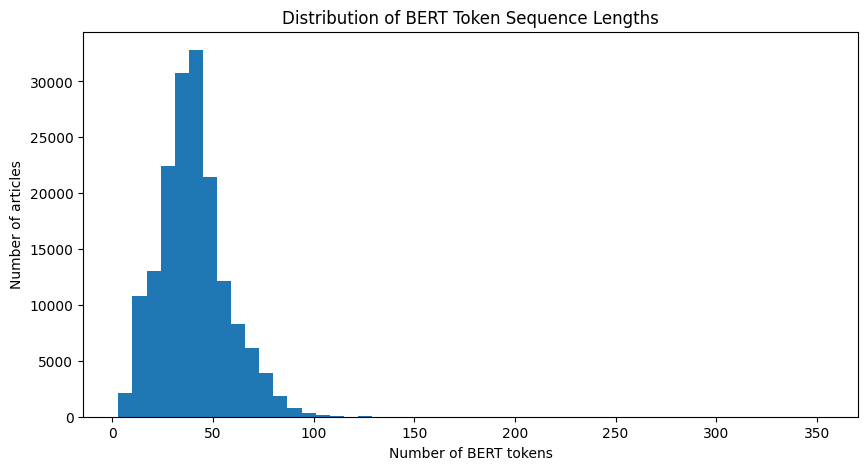

In [44]:
plt.figure(figsize=(10, 5))

plt.hist(
    token_lengths,
    bins=50,
)

plt.xlabel("Number of BERT tokens")
plt.ylabel("Number of articles")
plt.title("Distribution of BERT Token Sequence Lengths")

plt.show()

In [46]:
max_length = 128

long_texts = (token_lengths > max_length).sum()
long_texts_percentage = long_texts / len(token_lengths) * 100

print(f"Texts longer than 128 tokens: {long_texts}")
print(f"Percentage: {long_texts_percentage:.2f}%")

Texts longer than 128 tokens: 160
Percentage: 0.10%


#### Maximum Sequence Length

The token length analysis shows that the news articles are relatively short:

- median sequence length: 38 tokens;
- 95% of articles contain no more than 71 tokens;
- 99% contain no more than 86 tokens;
- the maximum observed length is 353 tokens.

Based on this distribution, we use `max_length = 128`.

This length preserves the complete text for the vast majority of articles while
remaining substantially smaller than BERT's maximum sequence length of 512 tokens.

Articles longer than 128 tokens will be truncated.

Padding will be applied dynamically within each batch rather than padding every
article to 128 tokens, reducing unnecessary computation.

#### Label Encoding

The target variable `category` currently contains string labels such as
`POLITICS`, `SPORTS`, and `BUSINESS`.

For Transformer training, these category names must be represented as integer
class IDs because the classification loss operates on numerical target labels.

We create two mappings:

- `label2id` converts category names to integer IDs;
- `id2label` converts model predictions back to human-readable category names.

The same mapping is used for the training, validation, and test sets.

In [47]:
label2id = {
    label: idx
    for idx, label in enumerate(classes)
}

id2label = {
    idx: label
    for label, idx in label2id.items()
}

print(f"Number of labels: {len(label2id)}")

Number of labels: 42


In [48]:
train_df = train_df.copy()
validation_df = validation_df.copy()
test_df = test_df.copy()

train_df["label"] = train_df["category"].map(label2id)
validation_df["label"] = validation_df["category"].map(label2id)
test_df["label"] = test_df["category"].map(label2id)

In [49]:
train_df[
    ["category", "label"]
].head()

,category,label
192930,FOOD & DRINK,13
19841,ENTERTAINMENT,10
95734,WORLDPOST,41
22719,BUSINESS,3
91978,POLITICS,24


In [50]:
print(f"Train missing labels:      {train_df['label'].isna().sum()}")
print(f"Validation missing labels: {validation_df['label'].isna().sum()}")
print(f"Test missing labels:       {test_df['label'].isna().sum()}")

Train missing labels:      0
Validation missing labels: 0
Test missing labels:       0


#### Tokenization and Dataset Preparation

After encoding the target labels, the text must be converted into the input
representation expected by BERT.

The pretrained BERT tokenizer converts each article into:

- `input_ids` — integer IDs of BERT tokens;
- `attention_mask` — indicates which tokens contain actual text and which tokens
  are padding;
- `label` — the integer class ID created during label encoding.

The text is truncated to `max_length = 128`, which was selected based on the
token length distribution of the training set.

Padding is not applied during tokenization. Instead, dynamic padding will be
performed when batches are created, so each batch is padded only to the length
of its longest sequence.

This reduces unnecessary computation compared with padding every article to
128 tokens.

In [51]:
from datasets import Dataset as HFDataset

train_dataset = HFDataset.from_pandas(
    train_df[["text", "label"]],
    preserve_index=False,
)

validation_dataset = HFDataset.from_pandas(
    validation_df[["text", "label"]],
    preserve_index=False,
)

In [52]:
def tokenize_batch(batch):
    return bert_tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_length,
        padding=False,
    )

In [53]:
train_dataset = train_dataset.map(
    tokenize_batch,
    batched=True,
)

validation_dataset = validation_dataset.map(
    tokenize_batch,
    batched=True,
)

Map: 100%|██████████| 20902/20902 [00:01<00:00, 20834.75 examples/s]


In [54]:
train_dataset[0]

{'text': "‘Franch' Dressing's Origins Revealed By Breaking Bad Creator: We Try It Out (VIDEO) Unable to resist the rich history and flavor of this cross-breed dressing we made up a batch and tested it out on our lab",
 'label': 13,
 'input_ids': [101,
  1520,
  23151,
  2818,
  1005,
  11225,
  1005,
  1055,
  7321,
  3936,
  2011,
  4911,
  2919,
  8543,
  1024,
  2057,
  3046,
  2009,
  2041,
  1006,
  2678,
  1007,
  4039,
  2000,
  9507,
  1996,
  4138,
  2381,
  1998,
  14894,
  1997,
  2023,
  2892,
  1011,
  8843,
  11225,
  2057,
  2081,
  2039,
  1037,
  14108,
  1998,
  7718,
  2009,
  2041,
  2006,
  2256,
  6845,
  102],
 'token_type_ids': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  

In [55]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=bert_tokenizer,
)

#### Dynamic Padding and DataLoaders

The tokenized datasets contain sequences of different lengths.

Instead of padding every article to `max_length = 128`, we use dynamic padding.
For each batch, sequences are padded only to the length of the longest sequence
in that batch.

This reduces unnecessary computation while keeping all tensors within a batch
the same shape.

PyTorch `DataLoader` objects are then used to group individual examples into
mini-batches for training and validation.

The training data is shuffled between epochs, while the validation data keeps
a fixed order.

In [56]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=bert_tokenizer,
)

In [57]:
train_dataset = train_dataset.remove_columns(["text"])
validation_dataset = validation_dataset.remove_columns(["text"])

In [58]:
from torch.utils.data import DataLoader

batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=data_collator,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator,
)

In [59]:
batch = next(iter(train_loader))

for key, value in batch.items():
    print(f"{key}: {value.shape}")

input_ids: torch.Size([16, 79])
token_type_ids: torch.Size([16, 79])
attention_mask: torch.Size([16, 79])
labels: torch.Size([16])


#### BERT for Sequence Classification

We use the pretrained `bert-base-uncased` model and adapt it to our
42-class news classification task.

The pretrained BERT encoder already contains language representations learned
during pretraining. However, the original pretrained model does not contain a
classification head specifically trained for our news categories.

Therefore, a new classification layer with 42 outputs is added on top of BERT.

During fine-tuning:

- the pretrained BERT weights are used as the starting point;
- the new classification head learns to map BERT representations to our 42 categories;
- by default, the pretrained BERT parameters are also updated during training.

For each article, the model produces 42 logits, one for each category.

When the correct `labels` are provided, the model also computes the
multiclass classification loss automatically.

In [60]:
from transformers import AutoModelForSequenceClassification

num_labels = len(label2id)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    bert_model_name,
    num_labels=num_labels,
    label2id=label2id,
    id2label=id2label,
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 510.08it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoin

In [61]:
print(f"Hidden size: {bert_model.config.hidden_size}")
print(f"Number of labels: {bert_model.config.num_labels}")

Hidden size: 768
Number of labels: 42


In [62]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

bert_model = bert_model.to(device)

print(f"Device: {device}")

Device: cuda


In [63]:
batch = {
    key: value.to(device)
    for key, value in batch.items()
}

bert_model.eval()

with torch.no_grad():
    outputs = bert_model(**batch)

print(f"Logits shape: {outputs.logits.shape}")
print(f"Loss: {outputs.loss.item():.4f}")

Logits shape: torch.Size([16, 42])
Loss: 3.6465


#### Fine-Tuning Strategy

The classification head added on top of BERT is randomly initialized, while the
BERT backbone already contains useful pretrained language representations.

To reduce the risk of noisy gradients from the randomly initialized classifier
disturbing the pretrained BERT weights at the beginning of training, we use a
two-stage fine-tuning strategy.

##### Phase 1 — Train the Classification Head

The BERT backbone is temporarily frozen and only the newly initialized
classification head is trained.

This allows the classifier to first learn how to map BERT representations to
the 42 news categories without modifying the pretrained BERT weights.

##### Phase 2 — Fine-Tune BERT

After the classification head has learned a useful mapping, the BERT backbone
is unfrozen and the whole model is fine-tuned.

The backbone will use a smaller learning rate than the classification head
because its pretrained weights already contain useful information and should
only be adjusted gradually.

This is known as differential or discriminative learning rates.

##### Training Duration

The final number of epochs is not fixed in advance.

Instead, each phase is given a maximum epoch budget. After every epoch we
evaluate the model on the validation set and monitor:

- training loss;
- validation loss;
- validation Accuracy;
- validation Macro F1.

Early stopping is used when validation performance stops improving.

The model checkpoint with the best validation Macro F1 is retained rather than
simply using the model from the final epoch.

Macro F1 remains the primary model-selection metric because the dataset contains
a substantial class imbalance.

Class weights are not used in the first BERT experiment. Their effect will be
tested later as a separate controlled experiment.

In [64]:
for param in bert_model.bert.parameters():
    param.requires_grad = False

In [65]:
trainable_parameters = sum(
    p.numel()
    for p in bert_model.parameters()
    if p.requires_grad
)

total_parameters = sum(
    p.numel()
    for p in bert_model.parameters()
)

print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Total parameters:     {total_parameters:,}")
print(
    f"Trainable percentage: "
    f"{trainable_parameters / total_parameters * 100:.2f}%"
)

Trainable parameters: 32,298
Total parameters:     109,514,538
Trainable percentage: 0.03%


In [66]:
from torch.optim import AdamW

head_learning_rate = 1e-3

head_optimizer = AdamW(
    bert_model.classifier.parameters(),
    lr=head_learning_rate,
)

In [67]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_transformer(model, data_loader, device):
    model.eval()

    total_loss = 0
    total_examples = 0

    predictions = []
    labels = []

    with torch.no_grad():
        for batch in data_loader:
            batch = {
                key: value.to(device)
                for key, value in batch.items()
            }

            outputs = model(**batch)

            batch_size = batch["labels"].size(0)

            total_loss += outputs.loss.item() * batch_size
            total_examples += batch_size

            batch_predictions = outputs.logits.argmax(dim=-1)

            predictions.extend(
                batch_predictions.cpu().numpy()
            )

            labels.extend(
                batch["labels"].cpu().numpy()
            )

    loss = total_loss / total_examples
    accuracy = accuracy_score(labels, predictions)
    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro",
    )

    return {
        "loss": loss,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
    }

In [68]:
def train_head_one_epoch(
    model,
    data_loader,
    optimizer,
    device,
):
    model.train()

    # BERT is frozen, so we keep the backbone
    # in evaluation mode during Phase 1.
    model.bert.eval()

    total_loss = 0
    total_examples = 0

    for batch in data_loader:
        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        optimizer.zero_grad()

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()

        optimizer.step()

        batch_size = batch["labels"].size(0)

        total_loss += loss.item() * batch_size
        total_examples += batch_size

    return total_loss / total_examples

In [69]:
max_head_epochs = 5
patience = 2

In [70]:
import os

os.makedirs("checkpoints", exist_ok=True)

head_checkpoint_path = "checkpoints/bert_phase1_head.pt"

best_macro_f1 = -float("inf")
epochs_without_improvement = 0

head_history = []

for epoch in range(1, max_head_epochs + 1):
    train_loss = train_head_one_epoch(
        bert_model,
        train_loader,
        head_optimizer,
        device,
    )

    validation_metrics = evaluate_transformer(
        bert_model,
        validation_loader,
        device,
    )

    head_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "validation_loss": validation_metrics["loss"],
        "validation_accuracy": validation_metrics["accuracy"],
        "validation_macro_f1": validation_metrics["macro_f1"],
    })

    print(f"Epoch {epoch}/{max_head_epochs}")
    print(f"Train Loss:          {train_loss:.4f}")
    print(
        f"Validation Loss:     "
        f"{validation_metrics['loss']:.4f}"
    )
    print(
        f"Validation Accuracy: "
        f"{validation_metrics['accuracy']:.4f}"
    )
    print(
        f"Validation Macro F1: "
        f"{validation_metrics['macro_f1']:.4f}"
    )
    print()

    if validation_metrics["macro_f1"] > best_macro_f1:
        best_macro_f1 = validation_metrics["macro_f1"]
        epochs_without_improvement = 0

        torch.save(
            bert_model.classifier.state_dict(),
            head_checkpoint_path,
        )

        print("Saved new best classification head.\n")

    else:
        epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping.")
            break

Epoch 1/5
Train Loss:          2.4230
Validation Loss:     2.1110
Validation Accuracy: 0.4411
Validation Macro F1: 0.1985

Saved new best classification head.

Epoch 2/5
Train Loss:          2.1348
Validation Loss:     1.9903
Validation Accuracy: 0.4634
Validation Macro F1: 0.2585

Saved new best classification head.

Epoch 3/5
Train Loss:          2.0803
Validation Loss:     1.9559
Validation Accuracy: 0.4520
Validation Macro F1: 0.2589

Saved new best classification head.

Epoch 4/5
Train Loss:          2.0541
Validation Loss:     1.8903
Validation Accuracy: 0.4842
Validation Macro F1: 0.2887

Saved new best classification head.

Epoch 5/5
Train Loss:          2.0417
Validation Loss:     1.8592
Validation Accuracy: 0.4931
Validation Macro F1: 0.2880



In [71]:
bert_model.classifier.load_state_dict(
    torch.load(
        head_checkpoint_path,
        map_location=device,
    )
)

<All keys matched successfully>

##### Phase 1 Results

Training only the classification head improved validation performance steadily.

The best validation Macro F1 was:

- **Validation Macro F1:** `0.2887`
- **Validation Accuracy:** `0.4842`

The best Macro F1 was reached at epoch 4.

Although Macro F1 slightly decreased at epoch 5, validation loss continued to
decrease and validation accuracy increased. This suggests that the model had not
clearly started to overfit.

Phase 1 is used primarily to initialize the randomly created classification head
before fine-tuning the pretrained BERT backbone. Therefore, we retain the best
classification head and proceed to Phase 2 rather than continuing to optimize
the frozen-backbone model.

#### Phase 2 — Fine-Tuning the BERT Backbone

After training the randomly initialized classification head, the best Phase 1
classifier is restored and the pretrained BERT backbone is unfrozen.

The entire model is now trained end-to-end.

Different learning rates are used for the two parts of the model:

- the pretrained BERT backbone uses a small learning rate because its weights
  already contain useful language representations and should only be adjusted
  gradually;
- the classification head uses a larger learning rate because it is much newer
  and needs more adaptation to the downstream task.

This approach is known as differential or discriminative learning rates.

The final number of epochs is not fixed in advance. A maximum training budget
is specified, while validation loss, Accuracy, and Macro F1 are monitored after
each epoch.

The checkpoint with the highest validation Macro F1 is retained, and training
is stopped early if validation performance stops improving.

In [73]:
for param in bert_model.bert.parameters():
    param.requires_grad = True

In [74]:
trainable_parameters = sum(
    p.numel()
    for p in bert_model.parameters()
    if p.requires_grad
)

total_parameters = sum(
    p.numel()
    for p in bert_model.parameters()
)

print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Total parameters:     {total_parameters:,}")
print(
    f"Trainable percentage: "
    f"{trainable_parameters / total_parameters * 100:.2f}%"
)

Trainable parameters: 109,514,538
Total parameters:     109,514,538
Trainable percentage: 100.00%


In [75]:
backbone_learning_rate = 2e-5
head_learning_rate = 1e-4

fine_tuning_optimizer = AdamW(
    [
        {
            "params": bert_model.bert.parameters(),
            "lr": backbone_learning_rate,
        },
        {
            "params": bert_model.classifier.parameters(),
            "lr": head_learning_rate,
        },
    ]
)

In [76]:
for i, param_group in enumerate(
    fine_tuning_optimizer.param_groups
):
    print(
        f"Parameter group {i + 1}: "
        f"learning rate = {param_group['lr']}"
    )

Parameter group 1: learning rate = 2e-05
Parameter group 2: learning rate = 0.0001


In [77]:
def train_model_one_epoch(
    model,
    data_loader,
    optimizer,
    device,
):
    model.train()

    total_loss = 0
    total_examples = 0

    for batch in data_loader:
        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        optimizer.zero_grad()

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()

        optimizer.step()

        batch_size = batch["labels"].size(0)

        total_loss += loss.item() * batch_size
        total_examples += batch_size

    return total_loss / total_examples

In [78]:
max_fine_tuning_epochs = 6
early_stopping_patience = 2

In [79]:
fine_tuning_checkpoint_path = (
    "checkpoints/bert_phase2_best.pt"
)

best_macro_f1 = -float("inf")
epochs_without_improvement = 0

fine_tuning_history = []

for epoch in range(
    1,
    max_fine_tuning_epochs + 1,
):
    train_loss = train_model_one_epoch(
        bert_model,
        train_loader,
        fine_tuning_optimizer,
        device,
    )

    validation_metrics = evaluate_transformer(
        bert_model,
        validation_loader,
        device,
    )

    fine_tuning_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "validation_loss": validation_metrics["loss"],
        "validation_accuracy": validation_metrics["accuracy"],
        "validation_macro_f1": validation_metrics["macro_f1"],
    })

    print(
        f"Epoch {epoch}/"
        f"{max_fine_tuning_epochs}"
    )
    print(
        f"Train Loss:          "
        f"{train_loss:.4f}"
    )
    print(
        f"Validation Loss:     "
        f"{validation_metrics['loss']:.4f}"
    )
    print(
        f"Validation Accuracy: "
        f"{validation_metrics['accuracy']:.4f}"
    )
    print(
        f"Validation Macro F1: "
        f"{validation_metrics['macro_f1']:.4f}"
    )
    print()

    if (
        validation_metrics["macro_f1"]
        > best_macro_f1
    ):
        best_macro_f1 = (
            validation_metrics["macro_f1"]
        )

        epochs_without_improvement = 0

        torch.save(
            bert_model.state_dict(),
            fine_tuning_checkpoint_path,
        )

        print(
            "Saved new best BERT checkpoint.\n"
        )

    else:
        epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= early_stopping_patience
        ):
            print("Early stopping.")
            break

Epoch 1/6
Train Loss:          1.1410
Validation Loss:     0.9799
Validation Accuracy: 0.7001
Validation Macro F1: 0.5966

Saved new best BERT checkpoint.

Epoch 2/6
Train Loss:          0.8022
Validation Loss:     0.9626
Validation Accuracy: 0.7107
Validation Macro F1: 0.6193

Saved new best BERT checkpoint.

Epoch 3/6
Train Loss:          0.5617
Validation Loss:     1.0487
Validation Accuracy: 0.7049
Validation Macro F1: 0.6114

Epoch 4/6
Train Loss:          0.3733
Validation Loss:     1.1988
Validation Accuracy: 0.7035
Validation Macro F1: 0.6120

Early stopping.


In [82]:
bert_model.load_state_dict(
    torch.load(
        fine_tuning_checkpoint_path,
        map_location=device,
    )
)

<All keys matched successfully>

##### Phase 2 Results

Fine-tuning the BERT backbone substantially improved validation performance.

The best model was obtained at epoch 2:

- **Validation Loss:** `0.9626`
- **Validation Accuracy:** `0.7107`
- **Validation Macro F1:** `0.6193`

After epoch 2, training loss continued to decrease while validation loss
increased and validation Macro F1 stopped improving. This indicates the
beginning of overfitting.

Early stopping was triggered after two consecutive epochs without improvement
in validation Macro F1.

The checkpoint from epoch 2 is therefore retained as the final BERT model.

Compared with previous models:

| Model | Validation Macro F1 |
|---|---:|
| TF-IDF + Logistic Regression + Class Weights | 0.4788 |
| Frozen BERT + Classification Head | 0.2887 |
| Fine-Tuned BERT | **0.6193** |

The large improvement from the frozen BERT model to the fine-tuned BERT model
shows that adapting the pretrained backbone to the downstream news
classification task is important for this dataset.

In [83]:
bert_model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [84]:
best_validation_metrics = evaluate_transformer(
    bert_model,
    validation_loader,
    device,
)

print(
    f"Validation Loss:     "
    f"{best_validation_metrics['loss']:.4f}"
)
print(
    f"Validation Accuracy: "
    f"{best_validation_metrics['accuracy']:.4f}"
)
print(
    f"Validation Macro F1: "
    f"{best_validation_metrics['macro_f1']:.4f}"
)

Validation Loss:     0.9626
Validation Accuracy: 0.7107
Validation Macro F1: 0.6193


In [85]:
def get_transformer_predictions(
    model,
    data_loader,
    device,
):
    model.eval()

    predictions = []
    labels = []

    with torch.no_grad():
        for batch in data_loader:
            batch = {
                key: value.to(device)
                for key, value in batch.items()
            }

            outputs = model(**batch)

            batch_predictions = (
                outputs.logits.argmax(dim=-1)
            )

            predictions.extend(
                batch_predictions.cpu().numpy()
            )

            labels.extend(
                batch["labels"].cpu().numpy()
            )

    return labels, predictions

In [86]:
validation_labels, validation_predictions = (
    get_transformer_predictions(
        bert_model,
        validation_loader,
        device,
    )
)

In [87]:
print(
    classification_report(
        validation_labels,
        validation_predictions,
        labels=list(range(len(classes))),
        target_names=classes,
        digits=3,
        zero_division=0,
    )
)

                precision    recall  f1-score   support

          ARTS      0.520     0.616     0.564       151
ARTS & CULTURE      0.558     0.575     0.566       134
  BLACK VOICES      0.480     0.638     0.548       458
      BUSINESS      0.596     0.654     0.624       599
       COLLEGE      0.679     0.461     0.549       115
        COMEDY      0.637     0.579     0.606       539
         CRIME      0.633     0.683     0.657       356
CULTURE & ARTS      0.712     0.486     0.578       107
       DIVORCE      0.886     0.822     0.853       342
     EDUCATION      0.421     0.578     0.488       102
 ENTERTAINMENT      0.776     0.774     0.775      1736
   ENVIRONMENT      0.713     0.531     0.609       145
         FIFTY      0.559     0.507     0.532       140
  FOOD & DRINK      0.699     0.833     0.760       634
     GOOD NEWS      0.483     0.307     0.376       140
         GREEN      0.507     0.576     0.539       262
HEALTHY LIVING      0.571     0.526     0.548  

In [88]:
fine_tuning_history_df = pd.DataFrame(
    fine_tuning_history
)

fine_tuning_history_df

,epoch,train_loss,validation_loss,validation_accuracy,validation_macro_f1
0,1,1.141010,0.979906,0.700124,0.596609
1,2,0.802168,0.962640,0.710745,0.619251
2,3,0.561708,1.048676,0.704909,0.611382
3,4,0.373316,1.198800,0.703473,0.612046


##### Learning Curves

To analyze the training dynamics, we plot training and validation loss together
with the validation Accuracy and Macro F1 across epochs.

Training loss continued to decrease throughout fine-tuning, while validation
loss reached its minimum at epoch 2 and increased afterwards.

Validation Macro F1 also reached its best value at epoch 2 and did not improve
during the following two epochs.

This divergence between training and validation performance indicates the
beginning of overfitting and confirms that the checkpoint selected by early
stopping was preferable to the model from the final epoch.

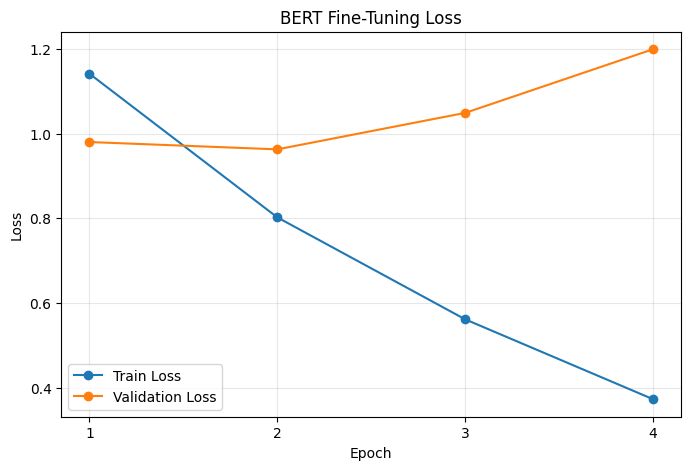

In [89]:
plt.figure(figsize=(8, 5))

plt.plot(
    fine_tuning_history_df["epoch"],
    fine_tuning_history_df["train_loss"],
    marker="o",
    label="Train Loss",
)

plt.plot(
    fine_tuning_history_df["epoch"],
    fine_tuning_history_df["validation_loss"],
    marker="o",
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BERT Fine-Tuning Loss")
plt.xticks(fine_tuning_history_df["epoch"])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

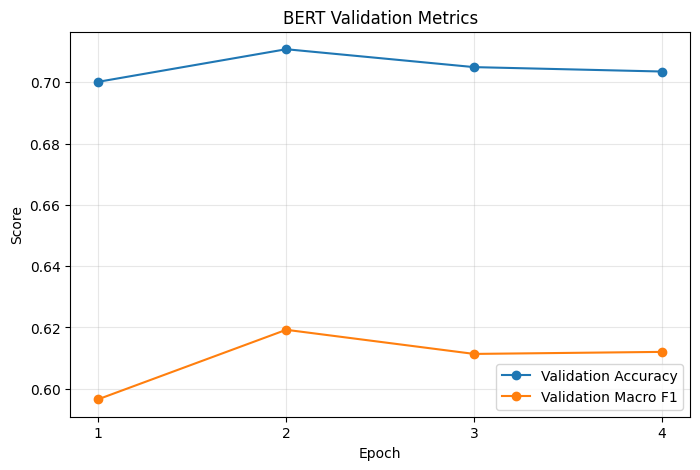

In [90]:
plt.figure(figsize=(8, 5))

plt.plot(
    fine_tuning_history_df["epoch"],
    fine_tuning_history_df[
        "validation_accuracy"
    ],
    marker="o",
    label="Validation Accuracy",
)

plt.plot(
    fine_tuning_history_df["epoch"],
    fine_tuning_history_df[
        "validation_macro_f1"
    ],
    marker="o",
    label="Validation Macro F1",
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("BERT Validation Metrics")
plt.xticks(fine_tuning_history_df["epoch"])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [91]:
print(
    f1_score(
        validation_labels,
        validation_predictions,
        average="macro",
    )
)

0.6192509234603681


In [92]:
best_validation_metrics["macro_f1"]

0.6192509234603681

##### Confusion Analysis

The classification report shows the performance of BERT for each category,
but it does not show which categories are confused with each other.

To analyze these errors, we use a confusion matrix.

Each row represents the true category, while each column represents the
category predicted by the model.

Because the dataset contains 42 imbalanced classes, the confusion matrix is
normalized by the true class. This makes the values comparable across both
large and small categories.

Values on the main diagonal represent correct predictions, while values outside
the diagonal represent classification errors.

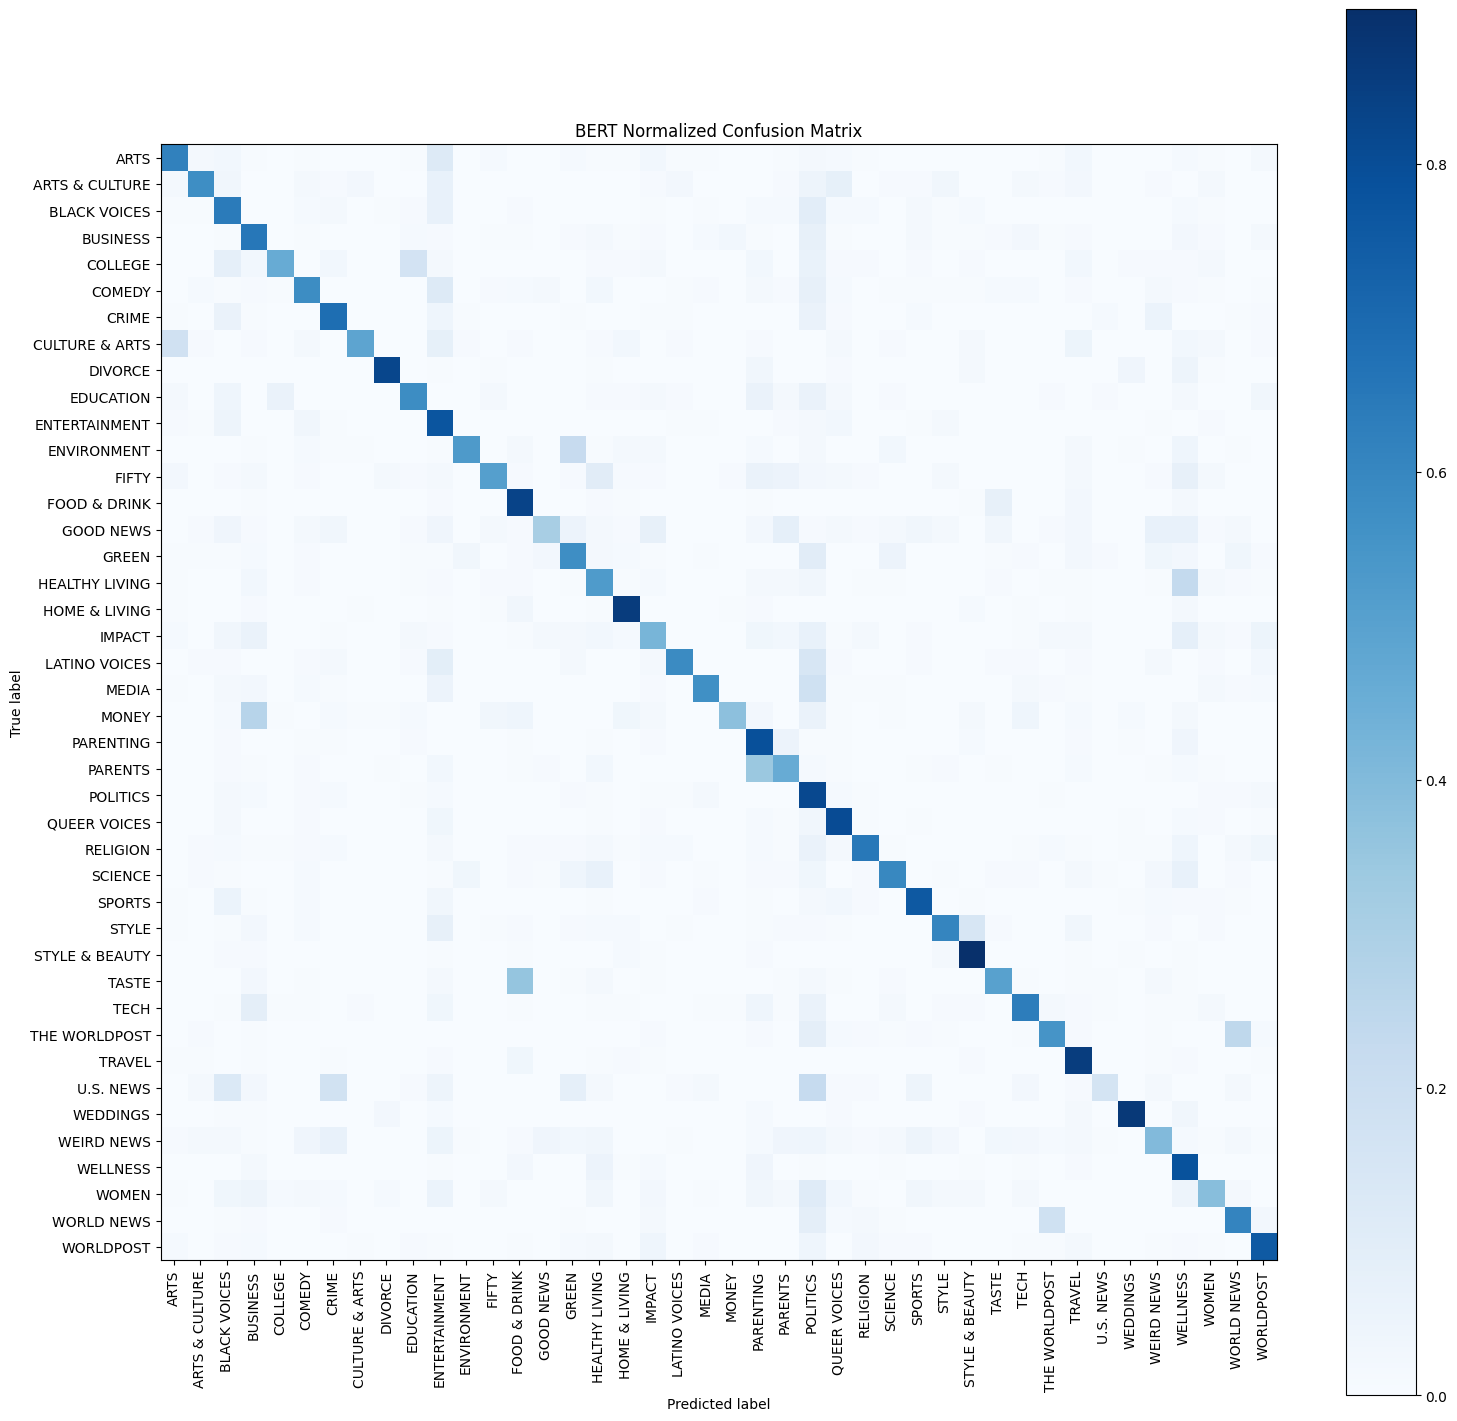

In [93]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

confusion_matrix_normalized = confusion_matrix(
    validation_labels,
    validation_predictions,
    labels=list(range(len(classes))),
    normalize="true",
)

fig, ax = plt.subplots(figsize=(18, 18))

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_normalized,
    display_labels=classes,
)

display.plot(
    ax=ax,
    cmap="Blues",
    include_values=False,
    xticks_rotation=90,
)

plt.title("BERT Normalized Confusion Matrix")
plt.show()

In [94]:
confusion_matrix_counts = confusion_matrix(
    validation_labels,
    validation_predictions,
    labels=list(range(len(classes))),
)

In [95]:
confusion_pairs = []

for true_id in range(len(classes)):
    true_total = confusion_matrix_counts[true_id].sum()

    for predicted_id in range(len(classes)):
        if true_id == predicted_id:
            continue

        count = confusion_matrix_counts[
            true_id,
            predicted_id,
        ]

        if count == 0:
            continue

        confusion_pairs.append({
            "true_category": id2label[true_id],
            "predicted_category": id2label[predicted_id],
            "count": count,
            "percent_of_true_class": (
                count / true_total * 100
            ),
        })

confusion_pairs_df = pd.DataFrame(
    confusion_pairs
)

In [96]:
top_confusions = (
    confusion_pairs_df
    .sort_values(
        by="count",
        ascending=False,
    )
    .head(20)
)

top_confusions

,true_category,predicted_category,count,percent_of_true_class
401,HEALTHY LIVING,WELLNESS,154,23.019432
564,PARENTS,PARENTING,133,34.190231
942,WELLNESS,HEALTHY LIVING,93,5.183946
829,THE WORLDPOST,WORLD NEWS,89,24.316940
228,ENTERTAINMENT,BLACK VOICES,76,4.377880
772,TASTE,FOOD & DRINK,75,35.714286
616,POLITICS,WORLDPOST,68,1.911186
946,WELLNESS,PARENTING,65,3.623188
128,COMEDY,ENTERTAINMENT,63,11.688312
1008,WORLD NEWS,THE WORLDPOST,60,18.237082


##### Confusion Analysis Results

The normalized confusion matrix shows a strong main diagonal, indicating that
BERT correctly distinguishes most categories.

However, several substantial errors occur between semantically similar classes.

The most notable relative confusions include:

- `PARENTS → PARENTING` — approximately 34% of true `PARENTS` examples;
- `TASTE → FOOD & DRINK` — approximately 36%;
- `THE WORLDPOST → WORLD NEWS` — approximately 24%;
- `HEALTHY LIVING → WELLNESS` — approximately 23%;
- `MONEY → BUSINESS` — approximately 27%;
- `WORLD NEWS → THE WORLDPOST` — approximately 18%.

These errors suggest that many remaining mistakes are not completely unrelated
predictions, but confusions between categories with overlapping semantic meaning.

Absolute error counts must also be interpreted together with the size of each
class. For example, some frequent classes produce many errors in absolute terms
while the errors represent only a small percentage of the class.

Overall, the confusion analysis confirms that the fine-tuned BERT model learned
meaningful distinctions between most news categories, while closely related
categories remain the main source of classification errors.

### Experiment 2 — DistilBERT

The second Transformer experiment uses `distilbert-base-uncased`.

DistilBERT is a smaller Transformer model derived from BERT. The goal of this
experiment is to evaluate whether a lighter model can achieve comparable
classification quality on the same task.

To make the comparison with BERT as controlled as possible, we keep the same:

- training, validation, and test splits;
- `max_length = 128`;
- batch size;
- primary metric: Macro F1;
- additional metric: Accuracy;
- two-stage fine-tuning strategy;
- early stopping and best-checkpoint selection.

The test set remains untouched.

In [97]:
from transformers import AutoTokenizer

distilbert_model_name = "distilbert-base-uncased"

distilbert_tokenizer = AutoTokenizer.from_pretrained(
    distilbert_model_name,
    use_fast=True,
)

c:\Users\miste\anaconda3\envs\geron_ml\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\miste\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [98]:
from datasets import Dataset as HFDataset

distilbert_train_dataset = HFDataset.from_pandas(
    train_df[["text", "label"]],
    preserve_index=False,
)

distilbert_validation_dataset = HFDataset.from_pandas(
    validation_df[["text", "label"]],
    preserve_index=False,
)

In [99]:
def tokenize_distilbert_batch(batch):
    return distilbert_tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_length,
        padding=False,
    )

In [100]:
distilbert_train_dataset = (
    distilbert_train_dataset.map(
        tokenize_distilbert_batch,
        batched=True,
    )
)

distilbert_validation_dataset = (
    distilbert_validation_dataset.map(
        tokenize_distilbert_batch,
        batched=True,
    )
)

Map: 100%|██████████| 20902/20902 [00:01<00:00, 20856.26 examples/s]


In [101]:
distilbert_train_dataset = (
    distilbert_train_dataset.remove_columns(["text"])
)

distilbert_validation_dataset = (
    distilbert_validation_dataset.remove_columns(["text"])
)

In [102]:
distilbert_data_collator = DataCollatorWithPadding(
    tokenizer=distilbert_tokenizer,
)

In [103]:
distilbert_train_loader = DataLoader(
    distilbert_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=distilbert_data_collator,
)

distilbert_validation_loader = DataLoader(
    distilbert_validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=distilbert_data_collator,
)

In [104]:
distilbert_batch = next(
    iter(distilbert_train_loader)
)

for key, value in distilbert_batch.items():
    print(f"{key}: {value.shape}")

input_ids: torch.Size([16, 75])
token_type_ids: torch.Size([16, 75])
attention_mask: torch.Size([16, 75])
labels: torch.Size([16])


In [105]:
distilbert_model = (
    AutoModelForSequenceClassification.from_pretrained(
        distilbert_model_name,
        num_labels=len(label2id),
        label2id=label2id,
        id2label=id2label,
    )
)

distilbert_model = distilbert_model.to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 262.77it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [106]:
print(distilbert_model)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [107]:
distilbert_batch = {
    key: value.to(device)
    for key, value in distilbert_batch.items()
}

distilbert_model.eval()

with torch.no_grad():
    distilbert_outputs = distilbert_model(
        **distilbert_batch
    )

print(
    f"Logits shape: "
    f"{distilbert_outputs.logits.shape}"
)

print(
    f"Loss: "
    f"{distilbert_outputs.loss.item():.4f}"
)

Logits shape: torch.Size([16, 42])
Loss: 3.7429


#### Phase 1 — Training the DistilBERT Classification Head

As in the BERT experiment, the pretrained DistilBERT backbone is first frozen.

Unlike BERT, the DistilBERT classification head contains two trainable linear
layers:

- `pre_classifier`;
- `classifier`.

Both layers are trained during Phase 1, while the pretrained DistilBERT
backbone remains unchanged.

Validation performance is evaluated after every epoch. The checkpoint with the
highest validation Macro F1 is retained, and early stopping is used if the
metric stops improving.

In [108]:
for param in distilbert_model.distilbert.parameters():
    param.requires_grad = False

In [109]:
for name, param in distilbert_model.named_parameters():
    if param.requires_grad:
        print(name, param.numel())

pre_classifier.weight 589824
pre_classifier.bias 768
classifier.weight 32256
classifier.bias 42


In [110]:
trainable_parameters = sum(
    p.numel()
    for p in distilbert_model.parameters()
    if p.requires_grad
)

total_parameters = sum(
    p.numel()
    for p in distilbert_model.parameters()
)

print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Total parameters:     {total_parameters:,}")
print(
    f"Trainable percentage: "
    f"{trainable_parameters / total_parameters * 100:.2f}%"
)

Trainable parameters: 622,890
Total parameters:     66,985,770
Trainable percentage: 0.93%


In [111]:
from itertools import chain

distilbert_head_learning_rate = 1e-3

distilbert_head_optimizer = AdamW(
    chain(
        distilbert_model.pre_classifier.parameters(),
        distilbert_model.classifier.parameters(),
    ),
    lr=distilbert_head_learning_rate,
)

In [112]:
def train_frozen_head_one_epoch(
    model,
    backbone,
    data_loader,
    optimizer,
    device,
):
    model.train()

    # Keep the frozen backbone in evaluation mode.
    backbone.eval()

    total_loss = 0
    total_examples = 0

    for batch in data_loader:
        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        optimizer.zero_grad()

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        batch_size = batch["labels"].size(0)

        total_loss += loss.item() * batch_size
        total_examples += batch_size

    return total_loss / total_examples

In [113]:
max_distilbert_head_epochs = 5
early_stopping_patience = 2

In [114]:
distilbert_head_checkpoint_path = (
    "checkpoints/distilbert_phase1_head.pt"
)

In [115]:
best_macro_f1 = -float("inf")
epochs_without_improvement = 0

distilbert_head_history = []

for epoch in range(
    1,
    max_distilbert_head_epochs + 1,
):
    train_loss = train_frozen_head_one_epoch(
        distilbert_model,
        distilbert_model.distilbert,
        distilbert_train_loader,
        distilbert_head_optimizer,
        device,
    )

    validation_metrics = evaluate_transformer(
        distilbert_model,
        distilbert_validation_loader,
        device,
    )

    distilbert_head_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "validation_loss": validation_metrics["loss"],
        "validation_accuracy": validation_metrics["accuracy"],
        "validation_macro_f1": validation_metrics["macro_f1"],
    })

    print(
        f"Epoch {epoch}/"
        f"{max_distilbert_head_epochs}"
    )
    print(f"Train Loss:          {train_loss:.4f}")
    print(
        f"Validation Loss:     "
        f"{validation_metrics['loss']:.4f}"
    )
    print(
        f"Validation Accuracy: "
        f"{validation_metrics['accuracy']:.4f}"
    )
    print(
        f"Validation Macro F1: "
        f"{validation_metrics['macro_f1']:.4f}"
    )
    print()

    if validation_metrics["macro_f1"] > best_macro_f1:
        best_macro_f1 = validation_metrics["macro_f1"]
        epochs_without_improvement = 0

        torch.save(
            {
                "pre_classifier":
                    distilbert_model.pre_classifier.state_dict(),
                "classifier":
                    distilbert_model.classifier.state_dict(),
            },
            distilbert_head_checkpoint_path,
        )

        print(
            "Saved new best DistilBERT "
            "classification head.\n"
        )

    else:
        epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= early_stopping_patience
        ):
            print("Early stopping.")
            break

Epoch 1/5
Train Loss:          1.5705
Validation Loss:     1.4071
Validation Accuracy: 0.5897
Validation Macro F1: 0.4478

Saved new best DistilBERT classification head.

Epoch 2/5
Train Loss:          1.4193
Validation Loss:     1.3690
Validation Accuracy: 0.6003
Validation Macro F1: 0.4581

Saved new best DistilBERT classification head.

Epoch 3/5
Train Loss:          1.3762
Validation Loss:     1.3304
Validation Accuracy: 0.6117
Validation Macro F1: 0.4757

Saved new best DistilBERT classification head.

Epoch 4/5
Train Loss:          1.3507
Validation Loss:     1.3231
Validation Accuracy: 0.6109
Validation Macro F1: 0.4752

Epoch 5/5
Train Loss:          1.3314
Validation Loss:     1.3229
Validation Accuracy: 0.6116
Validation Macro F1: 0.4844

Saved new best DistilBERT classification head.



##### Phase 1 Results

Training the DistilBERT classification head improved validation performance
throughout the five-epoch training budget.

The best observed result was obtained at epoch 5:

- **Validation Loss:** `1.3229`
- **Validation Accuracy:** `0.6116`
- **Validation Macro F1:** `0.4844`

Early stopping was not triggered because validation Macro F1 improved again
during the final epoch.

Since Phase 1 is primarily used to initialize the randomly created
classification head before backbone fine-tuning, we retain the best head and
proceed to Phase 2 rather than further optimizing the frozen-backbone model.

In [117]:
distilbert_head_checkpoint = torch.load(
    distilbert_head_checkpoint_path,
    map_location=device,
)

distilbert_model.pre_classifier.load_state_dict(
    distilbert_head_checkpoint["pre_classifier"]
)

distilbert_model.classifier.load_state_dict(
    distilbert_head_checkpoint["classifier"]
)

<All keys matched successfully>

In [118]:
for param in distilbert_model.distilbert.parameters():
    param.requires_grad = True

In [119]:
from itertools import chain

distilbert_backbone_learning_rate = 2e-5
distilbert_head_learning_rate = 1e-4

distilbert_fine_tuning_optimizer = AdamW(
    [
        {
            "params": distilbert_model.distilbert.parameters(),
            "lr": distilbert_backbone_learning_rate,
        },
        {
            "params": chain(
                distilbert_model.pre_classifier.parameters(),
                distilbert_model.classifier.parameters(),
            ),
            "lr": distilbert_head_learning_rate,
        },
    ]
)

In [120]:
max_distilbert_fine_tuning_epochs = 6
early_stopping_patience = 2

distilbert_fine_tuning_checkpoint_path = (
    "checkpoints/distilbert_phase2_best.pt"
)

In [121]:
best_macro_f1 = -float("inf")
epochs_without_improvement = 0

distilbert_fine_tuning_history = []

for epoch in range(
    1,
    max_distilbert_fine_tuning_epochs + 1,
):
    train_loss = train_model_one_epoch(
        distilbert_model,
        distilbert_train_loader,
        distilbert_fine_tuning_optimizer,
        device,
    )

    validation_metrics = evaluate_transformer(
        distilbert_model,
        distilbert_validation_loader,
        device,
    )

    distilbert_fine_tuning_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "validation_loss": validation_metrics["loss"],
        "validation_accuracy": validation_metrics["accuracy"],
        "validation_macro_f1": validation_metrics["macro_f1"],
    })

    print(
        f"Epoch {epoch}/"
        f"{max_distilbert_fine_tuning_epochs}"
    )
    print(f"Train Loss:          {train_loss:.4f}")
    print(
        f"Validation Loss:     "
        f"{validation_metrics['loss']:.4f}"
    )
    print(
        f"Validation Accuracy: "
        f"{validation_metrics['accuracy']:.4f}"
    )
    print(
        f"Validation Macro F1: "
        f"{validation_metrics['macro_f1']:.4f}"
    )
    print()

    if validation_metrics["macro_f1"] > best_macro_f1:
        best_macro_f1 = validation_metrics["macro_f1"]
        epochs_without_improvement = 0

        torch.save(
            distilbert_model.state_dict(),
            distilbert_fine_tuning_checkpoint_path,
        )

        print(
            "Saved new best DistilBERT checkpoint.\n"
        )

    else:
        epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= early_stopping_patience
        ):
            print("Early stopping.")
            break

Epoch 1/6
Train Loss:          1.1432
Validation Loss:     1.0146
Validation Accuracy: 0.6918
Validation Macro F1: 0.5838

Saved new best DistilBERT checkpoint.

Epoch 2/6
Train Loss:          0.8653
Validation Loss:     0.9743
Validation Accuracy: 0.7093
Validation Macro F1: 0.6092

Saved new best DistilBERT checkpoint.

Epoch 3/6
Train Loss:          0.6584
Validation Loss:     1.0386
Validation Accuracy: 0.7083
Validation Macro F1: 0.6091

Epoch 4/6
Train Loss:          0.4826
Validation Loss:     1.2039
Validation Accuracy: 0.7041
Validation Macro F1: 0.6100

Saved new best DistilBERT checkpoint.

Epoch 5/6
Train Loss:          0.3550
Validation Loss:     1.3048
Validation Accuracy: 0.6984
Validation Macro F1: 0.6025

Epoch 6/6
Train Loss:          0.2661
Validation Loss:     1.5570
Validation Accuracy: 0.6923
Validation Macro F1: 0.5939

Early stopping.


##### Phase 2 Results

Fine-tuning the DistilBERT backbone substantially improved validation
performance.

The best validation Macro F1 was reached at epoch 4:

- **Validation Accuracy:** `0.7041`
- **Validation Macro F1:** `0.6100`

After this point, training loss continued to decrease while validation loss
increased and validation Macro F1 declined, indicating overfitting.

Early stopping was triggered after two consecutive epochs without improvement
in validation Macro F1.

The best DistilBERT checkpoint is therefore retained for final comparison.

In [122]:
distilbert_model.load_state_dict(
    torch.load(
        distilbert_fine_tuning_checkpoint_path,
        map_location=device,
    )
)

distilbert_model.eval()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [123]:
distilbert_best_validation_metrics = evaluate_transformer(
    distilbert_model,
    distilbert_validation_loader,
    device,
)

print(
    f"Validation Loss:     "
    f"{distilbert_best_validation_metrics['loss']:.4f}"
)
print(
    f"Validation Accuracy: "
    f"{distilbert_best_validation_metrics['accuracy']:.4f}"
)
print(
    f"Validation Macro F1: "
    f"{distilbert_best_validation_metrics['macro_f1']:.4f}"
)

Validation Loss:     1.2039
Validation Accuracy: 0.7041
Validation Macro F1: 0.6100


### Model Comparison

The trained models are compared on the same validation set.

Macro F1 is used as the primary model-selection metric because the dataset is
imbalanced and each of the 42 categories should contribute equally to the final
score.

Accuracy is reported as an additional metric.

The test set remains untouched during model selection.

In [124]:
model_comparison = pd.DataFrame({
    "model": [
        "TF-IDF + Logistic Regression + Class Weights",
        "BERT",
        "DistilBERT",
    ],
    "validation_accuracy": [
        weighted_baseline_results["validation_accuracy"],
        best_validation_metrics["accuracy"],
        distilbert_best_validation_metrics["accuracy"],
    ],
    "validation_macro_f1": [
        weighted_baseline_results["validation_macro_f1"],
        best_validation_metrics["macro_f1"],
        distilbert_best_validation_metrics["macro_f1"],
    ],
})

model_comparison

,model,validation_accuracy,validation_macro_f1
0,TF-IDF + Logistic Regression + Class Weights,0.553775,0.478843
1,BERT,0.710745,0.619251
2,DistilBERT,0.704143,0.609957


In [125]:
bert_distilbert_difference = (
    best_validation_metrics["macro_f1"]
    - distilbert_best_validation_metrics["macro_f1"]
)

print(
    f"BERT - DistilBERT Macro F1 difference: "
    f"{bert_distilbert_difference:.4f}"
)

BERT - DistilBERT Macro F1 difference: 0.0093


In [126]:
def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
    )


bert_parameters = count_parameters(bert_model)
distilbert_parameters = count_parameters(distilbert_model)

print(f"BERT parameters:       {bert_parameters:,}")
print(f"DistilBERT parameters: {distilbert_parameters:,}")

BERT parameters:       109,514,538
DistilBERT parameters: 66,985,770


In [128]:
logistic_regression_parameters = (
    weighted_baseline_model.coef_.size
    + weighted_baseline_model.intercept_.size
)

print(
    f"Logistic Regression parameters: "
    f"{logistic_regression_parameters:,}"
)

Logistic Regression parameters: 3,384,738


In [129]:
model_comparison["parameters"] = [
    logistic_regression_parameters,
    bert_parameters,
    distilbert_parameters,
]

model_comparison

,model,validation_accuracy,validation_macro_f1,parameters
0,TF-IDF + Logistic Regression + Class Weights,0.553775,0.478843,3384738
1,BERT,0.710745,0.619251,109514538
2,DistilBERT,0.704143,0.609957,66985770


#### Comparison Results

BERT achieved the best validation performance with a Macro F1 of approximately
`0.6193`.

DistilBERT achieved a very similar Macro F1 of approximately `0.6100`, trailing
BERT by less than `0.01`.

Both Transformer models substantially outperformed the classical TF-IDF +
Logistic Regression baseline.

BERT is therefore selected as the best model based on the predefined primary
metric, Validation Macro F1.

However, DistilBERT provides a competitive alternative because it achieves
nearly the same validation quality with a smaller model.